# Chapter 258 — Random Walks
### Part VIII: Probability

A random walk is the trajectory of a particle that at each step moves by a random displacement. The simplest version — the 1D symmetric random walk — is the gateway to Brownian motion, the diffusion equation, option pricing, polymer physics, and network theory.

What makes random walks special is that despite being defined by i.i.d. increments, they produce *correlated* trajectories. The position at time $n$ depends on all previous positions. Yet this correlation has a precise mathematical structure we can analyze exactly.

**Prerequisites:** Random Variables (ch247), Variance and Standard Deviation (ch250), Markov Chains (ch257), Central Limit Theorem (ch254).

## 1. The 1D Symmetric Random Walk

Let $X_1, X_2, \ldots$ be i.i.d. with $P(X_i = +1) = P(X_i = -1) = 1/2$. Define:

$$S_n = \sum_{k=1}^n X_k, \quad S_0 = 0$$

Key exact results:
- $\mathbb{E}[S_n] = 0$ (unbiased steps)
- $\text{Var}(S_n) = n$ (variance grows linearly)
- $\text{Std}(S_n) = \sqrt{n}$ (spread grows as square root)

The $\sqrt{n}$ growth is a fundamental signature of diffusion.

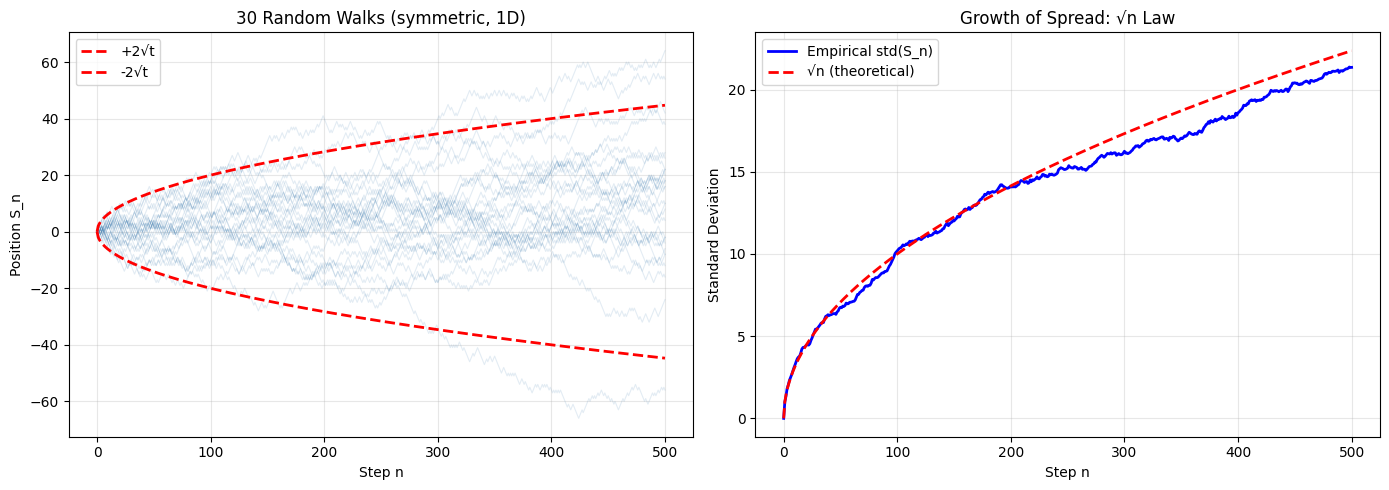

At n=500: empirical std = 21.35, √n = 22.36


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

def random_walk_1d(n_steps, n_walks, p=0.5, rng=None):
    """Simulate multiple 1D random walks.
    
    Args:
        n_steps: number of steps per walk
        n_walks: number of independent walks
        p: probability of step +1 (default 0.5 = symmetric)
        rng: numpy random generator
    
    Returns:
        positions: (n_steps+1, n_walks) array of positions
    """
    if rng is None:
        rng = np.random.default_rng()
    steps = rng.choice([-1, 1], size=(n_steps, n_walks), p=[1-p, p])
    positions = np.zeros((n_steps + 1, n_walks), dtype=int)
    positions[1:] = np.cumsum(steps, axis=0)
    return positions

n_steps = 500
n_walks = 200
walks = random_walk_1d(n_steps, n_walks, rng=rng)
t = np.arange(n_steps + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: individual walks + spread envelope
for i in range(min(30, n_walks)):
    axes[0].plot(t, walks[:, i], alpha=0.15, linewidth=0.8, color='steelblue')
axes[0].plot(t, 2*np.sqrt(t), 'r--', linewidth=2, label='+2√t')
axes[0].plot(t, -2*np.sqrt(t), 'r--', linewidth=2, label='-2√t')
axes[0].set_xlabel('Step n')
axes[0].set_ylabel('Position S_n')
axes[0].set_title('30 Random Walks (symmetric, 1D)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: std(S_n) vs sqrt(n)
empirical_std = np.std(walks, axis=1)
axes[1].plot(t, empirical_std, 'b-', label='Empirical std(S_n)', linewidth=2)
axes[1].plot(t, np.sqrt(t), 'r--', label='√n (theoretical)', linewidth=2)
axes[1].set_xlabel('Step n')
axes[1].set_ylabel('Standard Deviation')
axes[1].set_title('Growth of Spread: √n Law')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('random_walk_1d.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"At n={n_steps}: empirical std = {empirical_std[-1]:.2f}, √n = {np.sqrt(n_steps):.2f}")

## 2. The CLT View: Brownian Motion in the Limit

By the CLT *(ch254)*, $S_n / \sqrt{n} \to N(0,1)$ as $n \to \infty$. More precisely:

$$\frac{S_{\lfloor nt \rfloor}}{\sqrt{n}} \xrightarrow{d} B(t)$$

where $B(t)$ is **Brownian motion** (Wiener process). This is Donsker's theorem. The random walk is the discrete skeleton of Brownian motion.

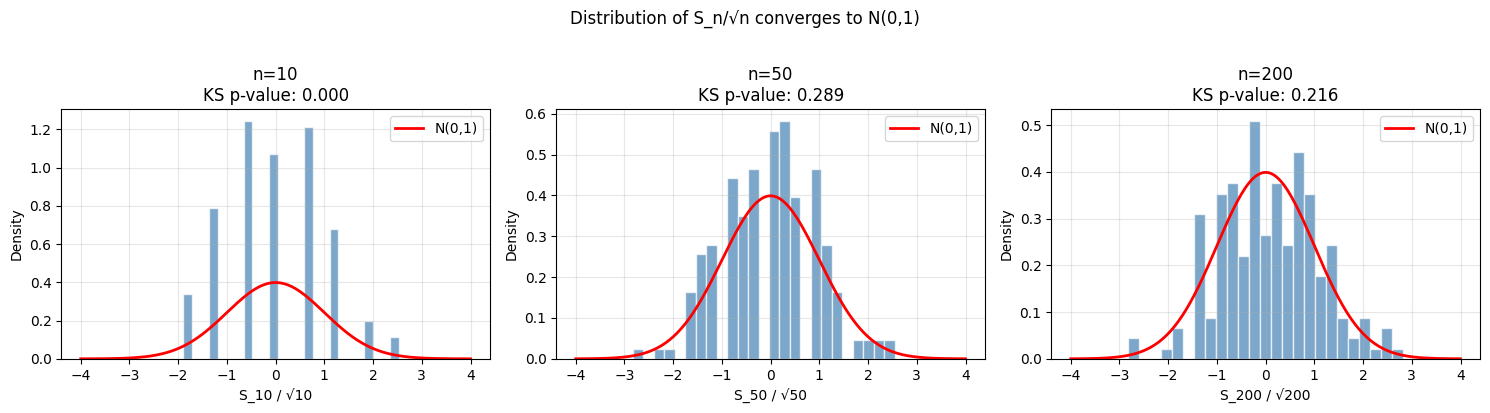

In [2]:
# Verify distribution of S_n is approximately Normal
ns_to_check = [10, 50, 200]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, n in zip(axes, ns_to_check):
    positions_at_n = walks[n, :]
    
    # Histogram
    ax.hist(positions_at_n / np.sqrt(n), bins=25, density=True,
            color='steelblue', alpha=0.7, edgecolor='white')
    
    # Overlay N(0,1)
    x_range = np.linspace(-4, 4, 200)
    ax.plot(x_range, stats.norm.pdf(x_range), 'r-', linewidth=2, label='N(0,1)')
    
    # QQ test
    ks_stat, ks_p = stats.kstest(positions_at_n / np.sqrt(n), 'norm')
    ax.set_title(f'n={n}\nKS p-value: {ks_p:.3f}')
    ax.set_xlabel(f'S_{n} / √{n}')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of S_n/√n converges to N(0,1)', y=1.02)
plt.tight_layout()
plt.savefig('random_walk_clt.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. First Passage Times and the Gambler's Ruin

How long does the walk take to first reach level $a > 0$? This is the **first passage time** $T_a = \min\{n : S_n = a\}$.

**Gambler's Ruin:** A gambler starts with $k$ dollars, plays against a casino with infinite funds, winning $1 with probability $p$ and losing $1 with probability $q = 1-p$. The probability of ruin (reaching 0) is:

$$P(\text{ruin} \mid S_0 = k) = \begin{cases} \left(\frac{q}{p}\right)^k & p \neq 1/2 \\ 1 & p = 1/2 \end{cases}$$

At $p = 1/2$, the symmetric walk is **recurrent** — it returns to every point infinitely often, and ruin is certain.

In [3]:
def gambler_ruin_simulation(k, target, p, n_trials, max_steps=50_000, rng=None):
    """Simulate Gambler's Ruin.
    
    Args:
        k: starting wealth
        target: winning target (reach this = win)
        p: probability of winning each bet
        n_trials: number of independent games to simulate
        max_steps: truncation (treat as draw if exceeded)
        rng: numpy random generator
    
    Returns:
        ruin_rate: fraction of games ending in ruin
        win_rate: fraction of games where target was reached
        mean_duration: mean game length (of completed games)
    """
    if rng is None:
        rng = np.random.default_rng()
    
    ruin_count = 0
    win_count = 0
    durations = []
    
    for _ in range(n_trials):
        wealth = k
        steps = 0
        while 0 < wealth < target and steps < max_steps:
            if rng.random() < p:
                wealth += 1
            else:
                wealth -= 1
            steps += 1
        
        if wealth == 0:
            ruin_count += 1
            durations.append(steps)
        elif wealth == target:
            win_count += 1
            durations.append(steps)
    
    return ruin_count/n_trials, win_count/n_trials, np.mean(durations) if durations else np.nan

# Compare fair vs biased games
k = 10  # starting wealth
target = 20  # win target
n_trials = 2000

print(f"Gambler's Ruin: start={k}, target={target}")
print(f"{'p':>6} {'Ruin prob (sim)':>16} {'Ruin prob (theory)':>20} {'Mean duration':>14}")
print("-" * 62)

for p in [0.4, 0.45, 0.5, 0.55, 0.6]:
    ruin_rate, win_rate, mean_dur = gambler_ruin_simulation(k, target, p, n_trials, rng=rng)
    
    q = 1 - p
    if abs(p - 0.5) < 1e-9:
        theory_ruin = 1 - k/target  # fair game: P(ruin|start k, target N) = 1 - k/N
    else:
        r = q/p
        theory_ruin = (r**k - r**target) / (1 - r**target)  # biased: Feller formula
    
    print(f"{p:>6.2f} {ruin_rate:>16.4f} {theory_ruin:>20.4f} {mean_dur:>14.1f}")

Gambler's Ruin: start=10, target=20
     p  Ruin prob (sim)   Ruin prob (theory)  Mean duration
--------------------------------------------------------------
  0.40           0.9810               0.9830           48.8
  0.45           0.8745               0.8815           75.6
  0.50           0.4820               0.5000           99.5
  0.55           0.1215               0.1185           76.5
  0.60           0.0155               0.0170           49.2


## 4. 2D Random Walks

In 2D, the walker moves N/S/E/W at each step. Key result: the 2D walk is also recurrent (returns to origin with probability 1). In 3D or higher, walks are **transient** — they escape to infinity. This is Pólya's theorem (1921).

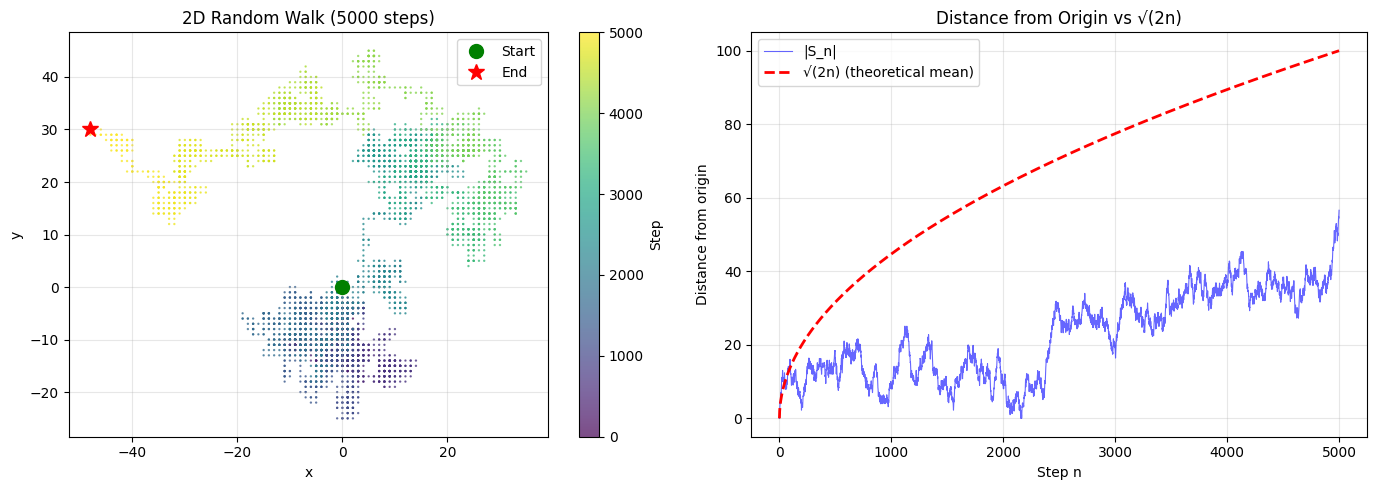

Final distance: 56.6
Theoretical E[|S_n|] ≈ √(2n) = 100.0


In [4]:
def random_walk_2d(n_steps, rng):
    """2D random walk on integer lattice (N/S/E/W)."""
    directions = np.array([[0,1],[0,-1],[1,0],[-1,0]])
    choices = rng.integers(0, 4, size=n_steps)
    steps = directions[choices]
    positions = np.zeros((n_steps + 1, 2), dtype=int)
    positions[1:] = np.cumsum(steps, axis=0)
    return positions

n_steps = 5000
walk_2d = random_walk_2d(n_steps, rng)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trajectory
sc = axes[0].scatter(walk_2d[:, 0], walk_2d[:, 1],
                     c=np.arange(n_steps+1), cmap='viridis',
                     s=0.5, alpha=0.7)
axes[0].plot(*walk_2d[0], 'go', markersize=10, label='Start', zorder=5)
axes[0].plot(*walk_2d[-1], 'r*', markersize=12, label='End', zorder=5)
plt.colorbar(sc, ax=axes[0], label='Step')
axes[0].set_title(f'2D Random Walk ({n_steps} steps)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Distance from origin over time
t = np.arange(n_steps + 1)
dist = np.sqrt(walk_2d[:, 0]**2 + walk_2d[:, 1]**2)
axes[1].plot(t, dist, 'b-', alpha=0.6, linewidth=0.8, label='|S_n|')
axes[1].plot(t, np.sqrt(2 * t), 'r--', linewidth=2, label='√(2n) (theoretical mean)')
axes[1].set_xlabel('Step n')
axes[1].set_ylabel('Distance from origin')
axes[1].set_title('Distance from Origin vs √(2n)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('random_walk_2d.png', dpi=120, bbox_inches='tight')
plt.show()

final_dist = dist[-1]
theoretical_mean = np.sqrt(2 * n_steps)
print(f"Final distance: {final_dist:.1f}")
print(f"Theoretical E[|S_n|] ≈ √(2n) = {theoretical_mean:.1f}")

## 5. Self-Avoiding Walks and Applications

A **self-avoiding walk (SAW)** must not revisit any site. SAWs model polymer chains in statistical physics — each monomer occupies a distinct location in space. Unlike simple random walks, SAWs are non-Markovian (future steps depend on all past positions).

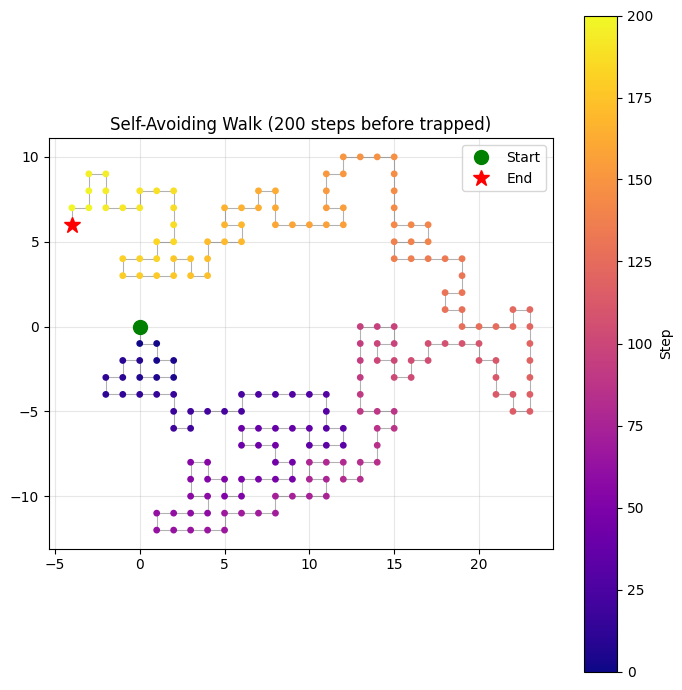

Walk length: 200 steps
End-to-end distance: 7.21
(Simple RW would give ~√n = 14.14)


In [5]:
def self_avoiding_walk(max_steps, rng, max_attempts=10000):
    """Generate a self-avoiding walk using backtracking (pivot-free version).
    Uses repeated attempts (not full backtracking) for simplicity.
    Returns the longest walk found within max_attempts tries.
    """
    directions = [(0,1),(0,-1),(1,0),(-1,0)]
    best_walk = [(0, 0)]
    
    for _ in range(max_attempts):
        visited = {(0, 0)}
        path = [(0, 0)]
        pos = (0, 0)
        
        for _ in range(max_steps):
            shuffled = rng.permutation(len(directions))
            moved = False
            for di in shuffled:
                dx, dy = directions[di]
                new_pos = (pos[0] + dx, pos[1] + dy)
                if new_pos not in visited:
                    visited.add(new_pos)
                    path.append(new_pos)
                    pos = new_pos
                    moved = True
                    break
            if not moved:  # trapped
                break
        
        if len(path) > len(best_walk):
            best_walk = path
    
    return best_walk

saw = self_avoiding_walk(max_steps=200, rng=rng, max_attempts=500)
saw_arr = np.array(saw)

fig, ax = plt.subplots(figsize=(7, 7))
n_pts = len(saw_arr)
sc = ax.scatter(saw_arr[:, 0], saw_arr[:, 1],
                c=np.arange(n_pts), cmap='plasma', s=15, zorder=3)
ax.plot(saw_arr[:, 0], saw_arr[:, 1], 'k-', alpha=0.3, linewidth=0.8)
ax.plot(*saw_arr[0], 'go', markersize=10, label='Start', zorder=5)
ax.plot(*saw_arr[-1], 'r*', markersize=12, label='End', zorder=5)
plt.colorbar(sc, ax=ax, label='Step')
ax.set_title(f'Self-Avoiding Walk ({n_pts-1} steps before trapped)')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('self_avoiding_walk.png', dpi=120, bbox_inches='tight')
plt.show()

end_to_end = np.sqrt(((saw_arr[-1] - saw_arr[0])**2).sum())
print(f"Walk length: {n_pts-1} steps")
print(f"End-to-end distance: {end_to_end:.2f}")
print(f"(Simple RW would give ~√n = {np.sqrt(n_pts-1):.2f})")

## 6. Summary

| Property | 1D Symmetric RW | Result |
|----------|----------------|--------|
| Mean position | $\mathbb{E}[S_n] = 0$ | Unbiased |
| Spread | $\text{Std}(S_n) = \sqrt{n}$ | Diffusive scaling |
| Distribution | $S_n/\sqrt{n} \to N(0,1)$ | CLT applies |
| Recurrence (1D, 2D) | Returns to origin w.p. 1 | Pólya's theorem |
| Transience (3D+) | Escapes to infinity | Pólya's theorem |
| Gambler's ruin (fair) | Ruin prob = $1 - k/N$ | Always ruins eventually |

## 9. Forward References

- **ch259 — Simulation Techniques**: Builds general simulation infrastructure for SDEs (stochastic differential equations) — the continuous analog of random walks, used in finance (Black-Scholes) and physics.
- **ch279 — Correlation** *(Part IX)*: The autocovariance $\text{Cov}(S_m, S_n) = \min(m,n)$ captures how random walk positions are correlated — a direct application of covariance structure.